# A/B-тест: Новый онбординг vs Контроль
**Бизнес-кейс:** Продуктовая команда тестирует редизайн онбординг-флоу  
**Гипотеза H₁:** 7-day Activation Rate в группе B (новый онбординг) выше, чем в группе A  
**Уровень значимости:** alpha = 0.05 | **Мощность:** beta = 0.80

In [1]:
import numpy as np
import pandas as pd
import scipy.stats as stats
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from datetime import datetime, timedelta

np.random.seed(42)
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({'figure.dpi': 120, 'font.size': 11})


## 1. Генерация данных
Синтетический датасет: 28 дней, 2 группы, ~6 000 пользователей суммарно

In [2]:
# параметры эксперимента
N_TOTAL        = 6_000        # общий трафик за 28 дней
SPLIT          = 0.50         # 50/50
CONTROL_RATE   = 0.31         # baseline activation rate
TREATMENT_RATE = 0.38         # ожидаемый эффект (+7 п.п.)
EXP_START      = datetime(2024, 1, 15)
EXP_DAYS       = 28

n_control   = int(N_TOTAL * SPLIT)
n_treatment = N_TOTAL - n_control

# генерация пользователей
def make_users(n, group, rate, start_date, days):
    user_ids = range(1 if group == 'control' else n_control + 1,
                     n + 1 if group == 'control' else n_control + n + 1)
    reg_dates = [start_date + timedelta(days=np.random.randint(0, days)) for _ in range(n)]
    activated = np.random.binomial(1, rate, n)
    # время активации: от 0 до 7 дней после регистрации (только для активированных)
    act_delay = [np.random.randint(0, 7) if act else None for act in activated]
    dropout   = np.random.binomial(1, 0.15 if group == 'control' else 0.09, n)  # guardrail
    onboard_time_sec = np.random.normal(
        420 if group == 'control' else 280, 60, n).clip(60, 900).astype(int)
    return pd.DataFrame({
        'user_id':          list(user_ids),
        'group':            group,
        'registered_at':    reg_dates,
        'activated_7d':     activated,
        'activation_delay': act_delay,
        'onboarding_dropout': dropout,
        'onboarding_time_sec': onboard_time_sec
    })

df_control   = make_users(n_control,   'control',   CONTROL_RATE,   EXP_START, EXP_DAYS)
df_treatment = make_users(n_treatment, 'treatment', TREATMENT_RATE, EXP_START, EXP_DAYS)
df = pd.concat([df_control, df_treatment], ignore_index=True)

print(f"Датасет: {len(df):,} пользователей")
print(df.groupby('group')[['user_id']].count().rename(columns={'user_id': 'n_users'}))
print("\nПервые строки:")
df.head()

Датасет: 6,000 пользователей
           n_users
group             
control       3000
treatment     3000

Первые строки:


,user_id,group,registered_at,activated_7d,activation_delay,onboarding_dropout,onboarding_time_sec
0,1,control,2024-01-21,0,NaN,0,376
1,2,control,2024-02-03,1,5.0,0,400
2,3,control,2024-01-29,1,0.0,0,323
3,4,control,2024-01-25,0,NaN,1,397
4,5,control,2024-01-22,0,NaN,0,491


## 2. Разведочный анализ (EDA)

In [ ]:
# базовые метрики по группам
summary = df.groupby('group').agg(
    n_users          = ('user_id', 'count'),
    activated        = ('activated_7d', 'sum'),
    activation_rate  = ('activated_7d', 'mean'),
    dropout_rate     = ('onboarding_dropout', 'mean'),
    avg_onboard_sec  = ('onboarding_time_sec', 'mean')
).round(4)
summary['activation_rate_pct'] = (summary['activation_rate'] * 100).round(2)
summary['dropout_rate_pct']    = (summary['dropout_rate']    * 100).round(2)
print(summary[['n_users', 'activated', 'activation_rate_pct',
               'dropout_rate_pct', 'avg_onboard_sec']])

           n_users  activated  activation_rate_pct  dropout_rate_pct  \
group                                                                  
control       3000        903                 30.1              15.3   
treatment     3000       1140                 38.0               9.1   

           avg_onboard_sec  
group                       
control           418.7650  
treatment         278.2113  


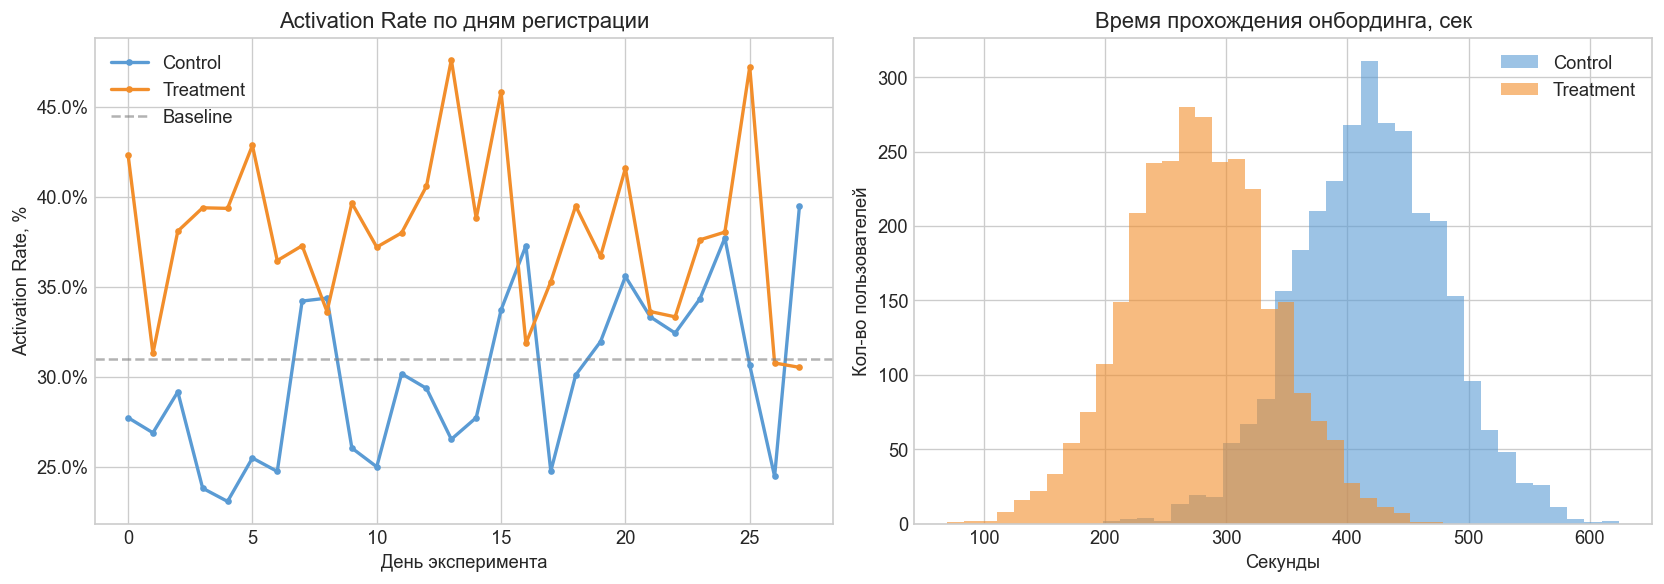

Графики сохранены в eda_plots.png


In [3]:
# накопительнеая динамика активации (дни)
df['reg_day'] = (df['registered_at'] - EXP_START).dt.days

daily = df.groupby(['reg_day', 'group'])['activated_7d'].mean().reset_index()
daily.columns = ['day', 'group', 'activation_rate']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ежедневная конверсия
for g, color in [('control', '#5a9bd4'), ('treatment', '#f28e2b')]:
    d = daily[daily['group'] == g]
    axes[0].plot(d['day'], d['activation_rate'] * 100,
                 label=f'{g.capitalize()}', color=color, linewidth=2, marker='o', markersize=3)
axes[0].axhline(CONTROL_RATE * 100, linestyle='--', color='gray', alpha=0.6, label='Baseline')
axes[0].set_title('Activation Rate по дням регистрации')
axes[0].set_xlabel('День эксперимента')
axes[0].set_ylabel('Activation Rate, %')
axes[0].yaxis.set_major_formatter(mtick.PercentFormatter())
axes[0].legend()

# время онбординга
for g, color in [('control', '#5a9bd4'), ('treatment', '#f28e2b')]:
    vals = df[df['group'] == g]['onboarding_time_sec']
    axes[1].hist(vals, bins=30, alpha=0.6, label=g.capitalize(), color=color)
axes[1].set_title('Время прохождения онбординга, сек')
axes[1].set_xlabel('Секунды')
axes[1].set_ylabel('Кол-во пользователей')
axes[1].legend()

plt.tight_layout()
plt.savefig('eda_plots.png', bbox_inches='tight')
plt.show()
print("Графики сохранены в eda_plots.png")

## 3. Проверка SRM (Sample Ratio Mismatch)
Перед любым статистическим тестом убеждаемся, что разбивка произошла корректно

In [5]:
n_ctrl = df[df['group'] == 'control'].shape[0]
n_trt  = df[df['group'] == 'treatment'].shape[0]
n_tot  = n_ctrl + n_trt
expected = n_tot * SPLIT

chi2_srm, p_srm = stats.chisquare([n_ctrl, n_trt], f_exp=[expected, n_tot - expected])

print(f"Контроль: {n_ctrl}  |  Treatment: {n_trt}  |  Ожидаемо: {expected:} / {n_tot-expected:}")
print(f"Chi‑square: {chi2_srm:.4f},  p-value: {p_srm:.4f}")
if p_srm > 0.05:
    print("SRM не обнаружен — разбивка корректна")
else:
    print("SRM обнаружен — результаты теста ненадёжны, требуется расследование!")

Контроль: 3000  |  Treatment: 3000  |  Ожидаемо: 3000.0 / 3000.0
Chi‑square: 0.0000,  p-value: 1.0000
SRM не обнаружен — разбивка корректна


## 4. Расчёт MDE и мощности
Проверяем, был ли тест достаточно мощным для обнаружения ожидаемого эффекта

In [8]:
from scipy.stats import norm

def calc_mde(n, baseline, alpha=0.05, power=0.80):
    """Мин обнаруживаемый эффект для двухвыборочного теста пропорций"""
    z_alpha = norm.ppf(1 - alpha / 2)
    z_beta  = norm.ppf(power)
    p_avg   = baseline
    sigma   = np.sqrt(2 * p_avg * (1 - p_avg) / n)
    return (z_alpha + z_beta) * sigma

n_per_group = min(n_ctrl, n_trt)
mde = calc_mde(n_per_group, CONTROL_RATE)

print(f"Пользователей на группу:       {n_per_group}")
print(f"Baseline rate:                 {CONTROL_RATE:.1%}")
print(f"MDE (alpha=0.05, beta=0.80):   {mde:.3f} ({mde*100:.2f} п.п.)")
print(f"Реальный эффект:               {TREATMENT_RATE - CONTROL_RATE:.3f} ({(TREATMENT_RATE-CONTROL_RATE)*100:.1f} п.п.)")
print()
if (TREATMENT_RATE - CONTROL_RATE) >= mde:
    print("Тест был мощным для обнаружения эффекта")
else:
    print("Тест может быть недостаточно мощным, рассмотреть увеличение выборки")

Пользователей на группу:       3000
Baseline rate:                 31.0%
MDE (alpha=0.05, beta=0.80):   0.033 (3.35 п.п.)
Реальный эффект:               0.070 (7.0 п.п.)

Тест был мощным для обнаружения эффекта


## 5. Статистический тест: z-test для пропорций

In [9]:
ctrl_activated = df[df['group'] == 'control']['activated_7d'].sum()
trt_activated  = df[df['group'] == 'treatment']['activated_7d'].sum()
n_ctrl_total   = df[df['group'] == 'control'].shape[0]
n_trt_total    = df[df['group'] == 'treatment'].shape[0]

p_ctrl = ctrl_activated / n_ctrl_total
p_trt  = trt_activated  / n_trt_total
uplift = p_trt - p_ctrl
uplift_rel = uplift / p_ctrl

# pooled z-test
p_pool = (ctrl_activated + trt_activated) / (n_ctrl_total + n_trt_total)
se = np.sqrt(p_pool * (1 - p_pool) * (1/n_ctrl_total + 1/n_trt_total))
z_stat = uplift / se
p_value = 2 * (1 - norm.cdf(abs(z_stat)))  # двусторонний

# 95% CI для разницы пропорций (без pooling)
se_ci = np.sqrt(p_ctrl*(1-p_ctrl)/n_ctrl_total + p_trt*(1-p_trt)/n_trt_total)
ci_lo = uplift - 1.96 * se_ci
ci_hi = uplift + 1.96 * se_ci

print("=" * 50)
print(f"  Control:   {p_ctrl:.4f} ({p_ctrl:.2%})")
print(f"  Treatment: {p_trt:.4f} ({p_trt:.2%})")
print(f"  Uplift:    {uplift:+.4f} ({uplift_rel:+.1%} relative)")
print(f"  95% CI:    [{ci_lo:+.4f}, {ci_hi:+.4f}]")
print(f"  z-stat:    {z_stat:.4f}")
print(f"  p-value:   {p_value:.6f}")
print("=" * 50)
alpha = 0.05
if p_value < alpha:
    print(f"Результат статистически значим (p < {alpha})")
    print(f"Отвергаем Нулевую гипотезу: новый онбординг ДЕЙСТВИТЕЛЬНО улучшает активацию")
else:
    print(f"Результат НЕ значим (p ≥ {alpha}). Нет оснований отвергнуть Нулевую гипотезу")

  Control:   0.3010 (30.10%)
  Treatment: 0.3800 (38.00%)
  Uplift:    +0.0790 (+26.2% relative)
  95% CI:    [+0.0551, +0.1029]
  z-stat:    6.4566
  p-value:   0.000000
Результат статистически значим (p < 0.05)
Отвергаем Нулевую гипотезу: новый онбординг ДЕЙСТВИТЕЛЬНО улучшает активацию


## 6. Bootstrap-CI для подтверждения
Bootstrap дублирует аналитический CI — используем для верификации и визуализации

Bootstrap 95% CI: [+0.0550, +0.1027]
Bootstrap p-value (одностороннее): 0.0000


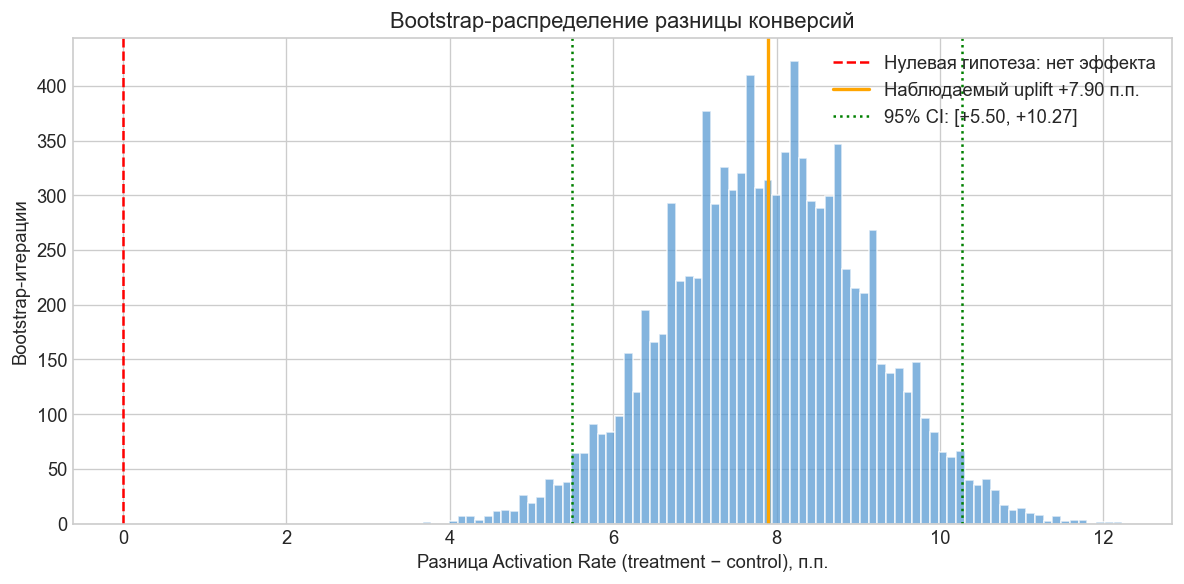

In [10]:
ctrl_vals = df[df['group'] == 'control']['activated_7d'].values
trt_vals  = df[df['group'] == 'treatment']['activated_7d'].values

N_BOOT = 10_000
boot_diffs = np.empty(N_BOOT)
for i in range(N_BOOT):
    bc = np.random.choice(ctrl_vals, size=len(ctrl_vals), replace=True)
    bt = np.random.choice(trt_vals,  size=len(trt_vals),  replace=True)
    boot_diffs[i] = bt.mean() - bc.mean()

boot_ci_lo, boot_ci_hi = np.percentile(boot_diffs, [2.5, 97.5])
boot_p_val = np.mean(boot_diffs <= 0)  # одностороннее p через бутстрэп

print(f"Bootstrap 95% CI: [{boot_ci_lo:+.4f}, {boot_ci_hi:+.4f}]")
print(f"Bootstrap p-value (одностороннее): {boot_p_val:.4f}")

fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(boot_diffs * 100, bins=80, color='#5a9bd4', alpha=0.75, edgecolor='white')
ax.axvline(0,                color='red',    linestyle='--', linewidth=1.5, label='Нулевая гипотеза: нет эффекта')
ax.axvline(uplift * 100,     color='orange', linestyle='-',  linewidth=2,   label=f'Наблюдаемый uplift {uplift*100:+.2f} п.п.')
ax.axvline(boot_ci_lo * 100, color='green',  linestyle=':',  linewidth=1.5, label=f'95% CI: [{boot_ci_lo*100:+.2f}, {boot_ci_hi*100:+.2f}]')
ax.axvline(boot_ci_hi * 100, color='green',  linestyle=':',  linewidth=1.5)
ax.set_xlabel('Разница Activation Rate (treatment − control), п.п.')
ax.set_ylabel('Bootstrap-итерации')
ax.set_title('Bootstrap-распределение разницы конверсий')
ax.legend()
plt.tight_layout()
plt.savefig('bootstrap_distribution.png', bbox_inches='tight')
plt.show()

## 7. Бизнес-интерпретация и рекомендация

In [13]:
#допущения для расчёта бизнес-эффекта
monthly_new_users = 10_000  # новые регистрации в месяц
avg_ltv_activated = 1_200   # средний LTV активированного пользователя (руб.)

additional_activated = monthly_new_users * uplift
additional_revenue   = additional_activated * avg_ltv_activated

print("=" * 55)
print("БИЗНЕС-ЭФФЕКТ (при масштабировании на весь трафик)")
print("=" * 55)
print(f"Ежемесячный трафик:          {monthly_new_users} пользователей")
print(f"Uplift:                      {uplift*100:+.2f} п.п.")
print(f"Доп. активированных/мес:     {additional_activated:,.0f}")
print(f"Доп. выручка/мес (при LTV):  {additional_revenue:,.0f} руб.")
print(f"Доп. выручка/год:            {additional_revenue * 12:,.0f} руб.")
print()
print("GUARDRAIL METRICS:")
dropout_ctrl = df[df['group']=='control']['onboarding_dropout'].mean()
dropout_trt  = df[df['group']=='treatment']['onboarding_dropout'].mean()
time_ctrl    = df[df['group']=='control']['onboarding_time_sec'].mean()
time_trt     = df[df['group']=='treatment']['onboarding_time_sec'].mean()
print(f"  Dropout rate:  control {dropout_ctrl:.1%} vs treatment {dropout_trt:.1%} снизился")
print(f"  Onboard time:  control {time_ctrl:.0f}s vs treatment {time_trt:.0f}s сократился")
print()
print("РЕКОМЕНДАЦИЯ: МАСШТАБИРОВАТЬ новый онбординг на 100% трафика.")
print(f"  Эффект значим (p={p_value:.4f} < 0.05), CI не включает 0,")
print(f"  guardrail-метрики улучшились, бизнес-эффект положительный")

БИЗНЕС-ЭФФЕКТ (при масштабировании на весь трафик)
Ежемесячный трафик:          10000 пользователей
Uplift:                      +7.90 п.п.
Доп. активированных/мес:     790
Доп. выручка/мес (при LTV):  948,000 руб.
Доп. выручка/год:            11,376,000 руб.

GUARDRAIL METRICS:
  Dropout rate:  control 15.3% vs treatment 9.1% снизился
  Onboard time:  control 419s vs treatment 278s сократился

РЕКОМЕНДАЦИЯ: МАСШТАБИРОВАТЬ новый онбординг на 100% трафика.
  Эффект значим (p=0.0000 < 0.05), CI не включает 0,
  guardrail-метрики улучшились, бизнес-эффект положительный
